# Workshop 3: Interactive Visualisation and Analysis of Copernicus Data

**Course:** Geospatial Processing  
**Lecturer:** Liliana Castillo Villamor  

---

## Introduction

This  workshop is designed to guide students through accessing, exploring, and processing geospatial datasets from the **Copernicus Data Space Ecosystem (CDSE)** using Python. Throughout this exercise, you will work directly with cloud-hosted S3 raster files, streamlining spatial workflows by eliminating the need to download large satellite imagery datasets locally.

---

## Workshop Objectives

By the end of this workshop, you will be able to:

1.  Understand the end-to-end workflow for dynamically integrating Earth Observation data using `leafmap`.
2. Utilise the GPU-accelerated rendering engine (`maplibregl`) to display raster overlays and vector basemaps with optimal performance.
3.Search and filter Sentinel-2 granules and Copernicus Land Monitoring Service (CLMS) products using S3 directory listings and the OData REST API over an Area of Interest (AOI).
4. Extract multi-dimensional arrays from satellite imagery to inspect metadata, compute statistical distributions, and prepare raster data for spectral analysis.

## Important concepts & Theoretical Background

Before embarking on the practical exercise, it is essential to understand the core technologies and platforms supporting this geospatial workflow:

### 1. Copernicus & Copernicus Data Space Ecosystem (CDSE)
**Copernicus** is the Earth Observation component of the European Union Space Programme, dedicated to monitoring our planet and its environment using the **Sentinel** satellite constellations and contributing Earth observation missions. 

The **Copernicus Data Space Ecosystem (CDSE)** is the official cloud infrastructure that provides open, direct access to petabytes of Earth Observation data. By offering S3-compatible object storage and RESTful OData search APIs, CDSE allows users to query, process, and stream satellite imagery directly into analytical environments without downloading massive raster files to local disks.
You can visually explore, filter, and inspect all available satellite collections interactively in your browser via the [Copernicus Browser](https://browser.dataspace.copernicus.eu/). However,full access to programmatic API services and cloud storage requires a free user account. You must register at the [Copernicus Data Space Ecosystem Portal](https://dataspace.copernicus.eu/) to generate your personal S3 access keys and API credentials.
>📚 **Official Documentation:** For comprehensive technical guides, API endpoints, authentication workflows, and dataset specifications, refer to the [CDSE Documentation Portal](https://documentation.dataspace.copernicus.eu/).
>
### 2. S3-Compatible Object Storage
**Amazon S3 (Simple Storage Service)** is the industry-standard API protocol for cloud-based object storage. An **S3-compatible** system—such as the Copernicus Data Space Ecosystem's `eodata` storage—is a non-Amazon cloud platform that implements the same API endpoints and communication protocols as AWS S3. 

In geospatial and Earth Observation workflows, S3 compatibility provides two major advantages:

* Industry-standard libraries and GDAL virtual file systems (such as `boto3`, `rasterio`, and `/vsis3/`) can interact directly with CDSE data without requiring proprietary or custom SDKs.
* It allows analytical tools to issue HTTP Range requests, reading spatial metadata and specific pixel sub-regions directly into memory from the cloud without downloading multi-gigabyte satellite granules to local disk.
> 💡 **What is an SDK?**
>
> **SDK** stands for **Software Development Kit**. It is a curated collection of software development tools, libraries, documentation, code samples, and APIs bundled into a single package to assist developers in building applications for a specific platform, framework, or cloud service.
>
> Rather than writing low-level code from scratch to interact with a complex remote system, the SDK provides ready-to-use building blocks.
>
> 📌 > **`boto3`** is the official **AWS SDK for Python**. Instead of manually constructing complex HTTP REST requests to authenticate and fetch satellite imagery from the Copernicus Data Space Ecosystem, `boto3` handles all low-level network protocols and credentials with just a few lines of Python code.

### 3. Leafmap
**`leafmap`** is an open-source Python library created for interactive mapping and spatial analysis within Jupyter notebook environments. It simplifies complex geospatial workflows by providing a unified interface to display vector layers, cloud-hosted rasters (such as Cloud Optimised GeoTIFFs), spatial web services, and satellite imagery catalogues with minimal code.

### 4. MapLibre GL
**MapLibre GL** is an open-source, WebGL-based mapping library used for rendering interactive vector and raster maps. Integrated into Python via **`leafmap.maplibregl`**, it utilises client-side GPU acceleration to deliver high-performance 2D and 3D map visualisations, smooth panning, dynamic layer styling, and rapid tile rendering directly within web browsers.

## 1.Environment Setup & Package Dependencies
Before running the workflow, several specialised Python libraries and GDAL drivers must be installed:

**leafmap**: An open-source Python library designed for interactive mapping and geospatial analysis within Jupyter notebooks. It simplifies visualising vector and raster data layers using interactive map backends (such as MapLibre GL).

**localtileserver**: A local tile server package that renders large spatial raster files (such as Cloud Optimised GeoTIFFs) directly onto interactive web maps without requiring prior disk downloads or manual sub-sampling.

**jupyter-server-proxy**: A Jupyter notebook extension that allows web-based applications (such as localtileserver) to run alongside the notebook and proxy HTTP requests securely.

**xarray**: A computational package for working with multi-dimensional labelled arrays, widely used for handling spatio-temporal Earth observation datasets.

**boto3**: The Amazon Web Services (AWS) SDK for Python. It allows programmatic access to S3-compatible cloud storage buckets, such as the Copernicus Data Space Ecosystem (eodata).

**libgdal-jp2openjpeg**: A GDAL plugin library providing engine support for reading JPEG 2000 (.jp2) image formats, which are extensively used across Sentinel-2 satellite products.

In [1]:
# Install core Python dependencies for geospatial visualisation and S3 access
# %pip install -U leafmap localtileserver jupyter-server-proxy xarray
# %pip install boto3

# Install GDAL JPEG2000 driver via Conda to ensure JP2 raster compatibility
# conda install -c conda-forge libgdal-jp2openjpeg


#In case local tile rendering service requires manual re-installation or update in your Python environment, install localtileserver for dynamic raster tile generation
# %pip install localtileserver


### 1.2. Import libraries

In [23]:
# --- Core System & Utility Modules ---
# Import operating system interfaces for managing environment credentials and file paths
import os

# Import regular expressions library for string pattern matching and metadata parsing
import re

# Import HTTP library for making API requests to remote cloud catalogue endpoints
import requests


# --- AWS Cloud Authentication & S3 Interface ---
# Import AWS SDK to interface with Copernicus S3-compatible cloud object storage
import boto3

# Import AWS authentication session handler for GDAL and Rasterio virtual file system (/vsis3/) access
from rasterio.session import AWSSession


# --- Geospatial & Numerical Processing Engines ---
# Import multi-dimensional array computation library for matrix operations and type casting
import numpy as np

# Import geospatial I/O library for accessing remote raster streams, metadata headers, and spatial masking
import rasterio

# Import multi-dimensional labelled data structure library for handling raster coordinates
import xarray as xr

# Import geospatial extension for Xarray to attach CRS and Affine transformation metadata directly in RAM
import rioxarray


# --- Data Visualisation & Mapping Libraries ---
# Import Matplotlib plotting engine for static multi-channel image preview rendering
import matplotlib.pyplot as plt

# Import Leafmap with MapLibre GL integration for GPU-accelerated 3D Web GIS map visualisations
import leafmap.maplibregl as leafmap

## 2. Authentication and Credential Setup (Copernicus S3 API)

To access Sentinel satellite imagery and Copernicus Land Monitoring Service (CLMS) products directly from the cloud, you need to obtain your own API credentials.

1. Follow the instructions in the [Official Copernicus S3 Documentation](https://documentation.dataspace.copernicus.eu/APIs/S3.html) to retrieve your personal access keys.
2. Replace the placeholder strings in `os.environ["AWS_ACCESS_KEY_ID"]` and `os.environ["AWS_SECRET_ACCESS_KEY"]` with your generated credentials before running the script.

In [3]:
os.environ["AWS_ACCESS_KEY_ID"] ="DLJ2C2K1BV2XOZHMCBSM"
os.environ["AWS_SECRET_ACCESS_KEY"] = "TFuWmCw6APYxS3eyeA1L6TUpn8SaKIc7gMfXg9hp"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

## 3. Exploring the Global Water Bodies Raster Path
Define the virtual file system S3 URL for the Global Water Bodies product 

In [4]:
url = "/vsis3/eodata/CLMS/bio-geophysical/water_bodies/wb_global_1km_10daily_v2/2018/01/01/c_gls_WB_201801010000_GLOBE_PROBAV_V2.1.1_cog/c_gls_WB-WB_201801010000_GLOBE_PROBAV_V2.1.1.tiff"

Read and inspect spatial metadata, coordinate reference system, and pixel dimensions

> ⚠️  If you encounter an `AttributeError: module 'ipyvuetify' has no attribute 'ExpansionPanelHeader'` when rendering `leafmap.maplibregl` map widgets, this is caused by a version mismatch. 
>
> Recent releases of `ipyvuetify` (version 3.x) updated to Vuetify 3, which renamed the `ExpansionPanelHeader` component to `ExpansionPanelTitle`. As older or stable builds of `leafmap` still reference the previous component name, the map rendering engine fails to initialise the widget sidebar.
>
> **How to fix it:**  
> Enforce an earlier, compatible version of `ipyvuetify` (`< 3.0`) in your environment setup before executing map widgets:
>
> ```python
> # Install compatible ipyvuetify version (< 3.0)
> %pip install "ipyvuetify<3"
> ```
>
> 📌 *Note: If you run this installation inside an active session, remember to restart your Jupyter kernel (**Kernel ➔ Restart Kernel**) for the updated package to take effect.*

### Inspect Raster Profile and Spatial Metadata
Read and inspect spatial metadata, coordinate reference system, and pixel dimensions

In [5]:
with rasterio.open(url) as src:
    print(src.profile)

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 251.0, 'width': 40320, 'height': 15680, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00892857142858361, 0.0, -180.00446428571428,
       0.0, -0.0089285714285694, 80.00446428571429), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}


### Visualise Water Bodies Layer on Interactive Globe Map

In [6]:
# Initialise an interactive 3D globe mapy
m = leafmap.Map(projection="globe")

# Add satellite basemap layer (initially set to hidden)
m.add_basemap("Esri.WorldImagery", visible=False)

# Overlay the cloud-hosted GeoTIFF raster using a blue colour palette for water features
m.add_raster(url, vmin=1, vmax=100, colormap="Blues", layer_name="Water Bodies")

# Render the interactive map widget
m

Html(children=[<leafmap.maplibregl.Map object at 0x0000019F26AF82F0>, Card(children=[Btn(children=[Icon(childr…

> 🌍 **How do we know `leafmap.Map(projection="globe")` creates a 3D view?**
>
> Rather than projecting spatial data onto a flat 2D plane (like standard Web Mercator `EPSG:3857`), MapLibre GL projects coordinate geometries onto a **3D spherical globe model**.
> Unlike standard 2D flat maps, a globe projection enables 3D camera controls, allowing you to tilt pitch, rotate bearing, and orbit around the planet in 3D space.

>💡 What is a Widget?
>
>In a Jupyter Notebook environment, a widget is an interactive, dynamic graphical element rendered directly within the output of a code cell. Unlike a static image (such as a standard plot generated by matplotlib), the object m created via leafmap is an ipywidgets-based component. It acts as a bridge between your Python code on the backend and a live JavaScript web interface on the frontend.
>
>It responds to state changes dynamically—such as toggling layer visibility or applying colormaps to raster overlays.


In [7]:
#%pip install localtileserver

## 4. Explore S3 Bucket Structure

In [25]:
# Define a  function to inspect directories and raster datasets in Copernicus S3
def list_s3_resources(prefix_path=""):
    """
    Lists sub-directories and raster files (.tif, .tiff, .jp2) 
    within the Copernicus 'eodata' S3 bucket for a given prefix path.
    """
    s3_client = boto3.client(
        "s3",
        aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
        aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
        endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
    )
    
    response = s3_client.list_objects_v2(
        Bucket="eodata",
        Prefix=prefix_path,
        Delimiter="/"
    )
    
    print(f"--- Contents in s3://eodata/{prefix_path} ---")
    
    # Print available subfolders and satellite collections
    folders = response.get("CommonPrefixes", [])
    for folder in folders:
        print(" 📁", folder.get("Prefix"))
        
    # Print raster data files if situated at the terminal folder level
    files = response.get("Contents", [])
    for file in files:
        key = file.get("Key")
        if key.endswith((".tif", ".tiff", ".jp2")):
            print(" 📄 /vsis3/eodata/" + key)

# List all primary satellite collections available at root level
list_s3_resources("")

--- Contents in s3://eodata/ ---
 📁 C3S/
 📁 CAMS/
 📁 CCM/
 📁 CEMS/
 📁 CLMS/
 📁 CLMS_archive/
 📁 Envisat-ASAR/
 📁 Envisat/
 📁 Global-Mosaics/
 📁 Jason-3/
 📁 Landsat-5/
 📁 Landsat-7/
 📁 SMOS/
 📁 SRTM/
 📁 Sentinel-1-RTC/
 📁 Sentinel-1/
 📁 Sentinel-2/
 📁 Sentinel-3/
 📁 Sentinel-5P/
 📁 Sentinel-6/
 📁 auxdata/
 📁 geoAI-embeddings/
 📁 geoAI-training/


In [26]:
list_s3_resources("Sentinel-2/MSI/")

--- Contents in s3://eodata/Sentinel-2/MSI/ ---
 📁 Sentinel-2/MSI/L1C/
 📁 Sentinel-2/MSI/L1C_N0500/
 📁 Sentinel-2/MSI/L2A/
 📁 Sentinel-2/MSI/L2A_N0500/
 📁 Sentinel-2/MSI/S2MSI_NIGHT/


## 5.Query Copernicus OData API for a Specific Region

In [27]:
# 're' (Regular Expressions): Built-in Python module used for string pattern matching and parsing specific text patterns (e.g. extracting  tile codes from S3 path strings)
import re

# 'requests': Standard HTTP library used to communicate with web services and query REST/OData APIs (e.g. fetching catalogue data from Copernicus)
import requests

# Target geographical coordinates for San Luis de Gaceno and timeframe of interest
LATITUDE = 4.8205
LONGITUDE = -73.1685
START_DATE = "2024-03-01"
END_DATE = "2024-03-31"


# Query the Copernicus Data Space Ecosystem catalogue using the OData API
def search_san_luis_odata(lat, lon, start_date, end_date):
    """Queries the Copernicus OData endpoint for Sentinel-2 Level-2A products
    intersecting a spatial bounding box around San Luis de Gaceno.
    Returns  A structured list containing metadata (index, date, MGRS tile code, and S3 object path)
        for each matching satellite scene.
    """
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

    # Define a bounding box spatial buffer (~10 km x 10 km grid) surrounding the target coordinates
    min_lon, max_lon = lon - 0.05, lon + 0.05
    min_lat, max_lat = lat - 0.05, lat + 0.05
    
    # Converts coordinate offsets into a Well-Known Text (WKT) closed POLYGON string (EPSG:4326)
    #The 'f' before the quotation marks indicates that the string is an f-string (formatted string literal, introduced in Python 3.6. 
    #Ittells Python to interpret and replace any variable or mathematical expression written within curly brackets {} with its actual value before generating the text.
    poly = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))"

    # Define query filters: Sentinel-2 collection + Level-2A surface reflectance (S2MSI2A) + Spatial intersection + Temporal range
    # Construct the OData filter criteria string combining:
        # 1. Collection target: Sentinel-2 satellite constellation
        # 2. Product level: S2MSI2A (Level-2A Bottom-Of-Atmosphere / Surface Reflectance)
        # 3. Spatial intersection: Intersects query polygon with scene footprint
        # 4. Temporal boundary: Start and end timestamp range (UTC format)
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poly}') and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z"
    )
    
# Organise API query parameters:
    # - $filter: Apply spatial, temporal, and product type constraints
    # - $orderby: Sort results chronologically with the latest acquisitions listed first
    # - $top: Cap the total number of returned entities to 50 items
    params = {
        "$filter": filter_query,
        "$orderby": "ContentDate/Start desc",  # Sort chronologically in descending order (most recent first)
        "$top": 50,
    }

    # Dispatch synchronous HTTP GET request to the Copernicus catalogue service
    response = requests.get(url, params=params)

    # Parse the JSON response body into a Python dictionary
    data = response.json()
    
    # Safely extract the list of dataset items from the 'value' key, defaulting to an empty list if absent
    items = data.get("value", [])
    
    # Initialise an empty list to store the processed metadata for each scene
    results = []
    print(f" Found {len(items)} matching Level-2A satellite scenes.\n" + "=" * 70)

    # Iterate through the catalogue items, obtaining both a zero-based index and the item object
    for idx, item in enumerate(items):
        # Retrieve the S3 bucket object path, defaulting to an empty string if key is absent allowiung the for to continue
        s3_path = item.get("S3Path", "")

        # Extract the start timestamp from nested dictionary and split at 'T' to isolate 'YYYY-MM-DD'
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]

        # # Search for the MGRS tile code pattern within the S3 path string (e.g. '_T18NYL_')
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else "T18NGL"

        # Append the parsed metadata as a structured dictionary to the accumulator list
        results.append(
            {"index": idx, "date": date, "tile": tile_id, "s3_path": s3_path}
        )

        print(f"[{idx}] 📅 Date: {date} | 🧩 Detected tile: {tile_id}")
        print(f"    📦 S3 path: {s3_path}\n")

    return results


# Execute the spatial-temporal query against the catalogue
coordinates_catalogue = search_san_luis_odata(
    LATITUDE, LONGITUDE, START_DATE, END_DATE
)

 Found 12 matching Level-2A satellite scenes.
[0] 📅 Date: 2024-03-30 | 🧩 Detected tile: T18NYL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/30/S2B_MSIL2A_20240330T151719_N0510_R125_T18NYL_20240330T191530.SAFE

[1] 📅 Date: 2024-03-30 | 🧩 Detected tile: T18NXL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/30/S2B_MSIL2A_20240330T151719_N0510_R125_T18NXL_20240330T191530.SAFE

[2] 📅 Date: 2024-03-25 | 🧩 Detected tile: T18NXL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/25/S2A_MSIL2A_20240325T151721_N0510_R125_T18NXL_20240325T202551.SAFE

[3] 📅 Date: 2024-03-25 | 🧩 Detected tile: T18NYL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/25/S2A_MSIL2A_20240325T151721_N0510_R125_T18NYL_20240325T202551.SAFE

[4] 📅 Date: 2024-03-20 | 🧩 Detected tile: T18NYL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/20/S2B_MSIL2A_20240320T151719_N0510_R125_T18NYL_20240320T205658.SAFE

[5] 📅 Date: 2024-03-20 | 🧩 Detected tile: T18NXL
    📦 S3 path: /eodata/Sentinel-2/MSI/L2A/2024/03/20/S2B_MSI

#### The MGRS Code Pattern in Sentinel-2

The **MGRS** (*Military Grid Reference System*) is a standard geographic coordinate system derived from the Universal Transverse Mercator (UTM) grid. For S-2 satellite data, the European Space Agency (ESA) partitions the Earth's surface into fixed geographic tiles measuring approximately $100\text{ km} \times 100\text{ km}$, allocating a unique MGRS code to each tile.

---

#### MGRS Tile Code Structure

A typical Sentinel-2 tile identifier, such as **`T18NYL`**, breaks down as follows:

| Component | Example | Description |
| :--- | :--- | :--- |
| **ESA Tile Prefix** | `T` | Denotes *"Tile"*, used as a standard prefix in Sentinel-2 file naming. |
| **UTM Zone** | `18` | Two-digit longitudinal zone number (ranging from `01` to `60`). |
| **Latitude Band** | `N` | Letter representing an $8^\circ$ latitudinal band (ranging from `C` to `X`). |
| **100 km Square ID** | `YL` | Two letters identifying the $100\text{ km}$ grid column (`Y`) and row (`L`). |

*Geographic Context:* The grid code **`18NYL`** covers the central region of Colombia, including Bogota and surrounding areas near San Luis de Gaceno.


### 5.1. Visualising imagery with matplotlib
#### 5.1.1. Load and Visualise one Band

> 💡 The JPEG 2000 (`.jp2`) Rasters**
>
> In the code below, the target file extension is **`.jp2`** (JPEG 2000). This is the standard, native raster format used by the European Space Agency (ESA) to store and distribute individual Sentinel-2 spectral bands within `.SAFE` product granules.
>
>
> * Unlike standard JPEG images that use discrete cosine transforms, JPEG 2000 utilises **discrete wavelet transform (DWT)** compression. This achieves high compression ratios while preserving critical radiometric fidelity and numerical precision required for scientific analysis.
> `.jp2` files embed full geospatial metadata directly into the file headers—including the Coordinate Reference System (CRS, e.g. UTM Zone 18N), pixel resolution (10 m, 20 m, or 60 m), and geographic origin.
> * JPEG 2000 files are structured hierarchically (in internal resolution pyramids or sub-samplings). When paired with GDAL's Virtual File System (`/vsis3/`) and `rasterio`, you can stream specific pixel bounding boxes or resolution levels directly over HTTP/S3 without downloading multi-megabyte image files to your local drive.

In [28]:

# 'AWSSession': Manages S3 authentication credentials and session parameters within Rasterio, enabling streaming access to remote raster datasets stored on cloud buckets
from rasterio.session import AWSSession

# 'matplotlib.pyplot': Core plotting module used to create figures, display multi-band raster arrays, and customise map visualisations
import matplotlib.pyplot as plt

# 1. Define the S3 path for the target .jp2 file
url_raster = "/vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/20/S2B_MSIL2A_20240320T151719_N0510_R125_T18NYL_20240320T205658.SAFE/GRANULE/L2A_T18NYL_A036759_20240320T151846/IMG_DATA/R10m/T18NYL_20240320T151719_B04_10m.jp2"

# 2. Initialise the boto3 session using credentials from environment variables
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")
if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"

rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

# 3. Open and read the raster dataset within the session environment
with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
    with rasterio.open(url_raster) as src:
        # Raster spatial metadata
        print("📐 Dimensions (height x width):", src.shape)
        print("🌍 Coordinate Reference System (CRS):", src.crs)
        print("📏 Pixel resolution:", src.res[0], "metres")
        print("📍 Bounding box (UTM):", src.bounds)
        
        # Read Band 1 into a NumPy array
        array_b04 = src.read(1)

# 4. Inspect numerical array properties
print("\n--- Pixel Array Properties ---")
print("Data type:", array_b04.dtype)
print("Minimum value:", array_b04.min())
print("Maximum value:", array_b04.max())

📐 Dimensions (height x width): (10980, 10980)
🌍 Coordinate Reference System (CRS): EPSG:32618
📏 Pixel resolution: 10.0 metres
📍 Bounding box (UTM): BoundingBox(left=699960.0, bottom=490200.0, right=809760.0, top=600000.0)

--- Pixel Array Properties ---
Data type: uint16
Minimum value: 1171
Maximum value: 20464


### 📍The `/vsis3/` File Path Prefix

The prefix **`/vsis3/`** stands for **Virtual System Interface for S3**. It is a specialized virtual file system handler provided by **GDAL** (Geospatial Data Abstraction Library).

* `vsi` (Virtual System Interface)ia an abstraction layer in GDAL that enables spatial libraries to treat remote cloud storage objects as if they were local files on your machine.
* `s3` (Simple Storage Service)specifies that the target file resides within an S3-compatible cloud object store (in this instance, the Copernicus Data Space Ecosystem S3 bucket).


#### Key Advantages

* It Eliminates Local Downloads: Without `/vsis3/`, you would have to download the entire Sentinel-2 `.SAFE` product folder (approx. 700 MB – 1 GB) to your hard drive before accessing a single band.
* By prepending `/vsis3/`, `rasterio` reads only the file metadata and streams the specific pixel subset (e.g., Band 04 at 10 m resolution clipped to your AOI) directly from the cloud into memory.


Mapping the raster using matplotlib

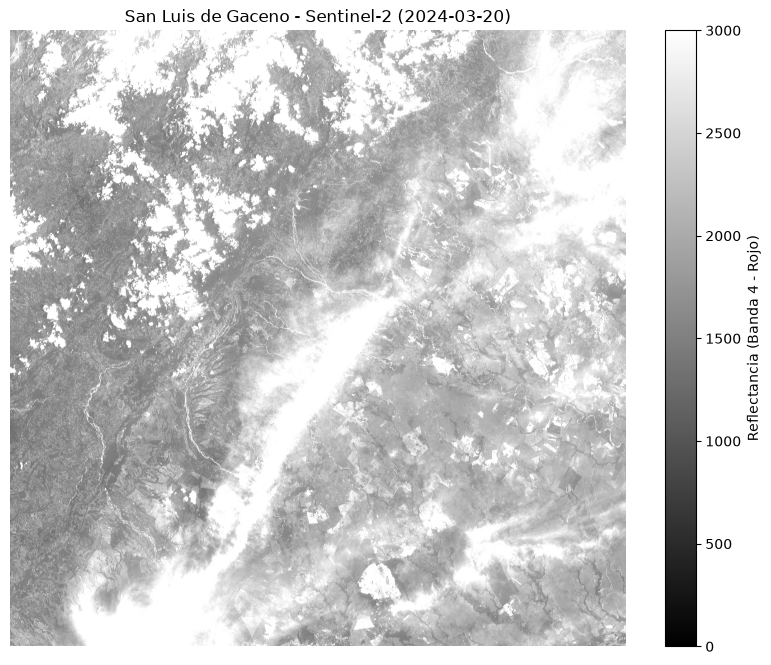

In [52]:
plt.figure(figsize=(10, 8))
plt.imshow(array_b04, cmap="gray", vmin=0, vmax=3000)
plt.colorbar(label="Reflectancia (Banda 4 - Rojo)")
plt.title("San Luis de Gaceno - Sentinel-2 (2024-03-20)")
plt.axis("off")
plt.show()

#### 5.1.2. Creating a True-Colour (RGB) Composite
To construct a natural True-Colour satellite image, we combine three individual 10-metre spectral bands:
* **Red Channel:** Band 4 (`B04_10m.jp2`)
* **Green Channel:** Band 3 (`B03_10m.jp2`)
* **Blue Channel:** Band 2 (`B02_10m.jp2`)

Because Matplotlib expects an image array with dimensions `(Height, Width, Channels)` scaled between `0.0` and `1.0` (or `0` to `255`), we stack the arrays along the third axis using `numpy.dstack()` and normalise the surface reflectance values.

> 💡 **What is a `boto3.Session`?**
>
> Is an isolated configuration object that stores user authentication credentials (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`) and connection settings.
>
> Pairing `boto3.Session` with `rasterio`'s **`AWSSession`** passes these credentials directly to GDAL's virtual file system (`/vsis3/`). This authenticates remote S3 requests behind the scenes, allowing `rasterio` to stream cloud-native satellite imagery directly into memory without downloading files to local disk.

In [53]:


# 1. Define S3 path for Band 4 (Red) and construct paths for Band 3 (Green) and Band 2 (Blue)
url_b04 = "/vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/20/S2B_MSIL2A_20240320T151719_N0510_R125_T18NYL_20240320T205658.SAFE/GRANULE/L2A_T18NYL_A036759_20240320T151846/IMG_DATA/R10m/T18NYL_20240320T151719_B04_10m.jp2"
url_b03 = url_b04.replace("B04_10m.jp2", "B03_10m.jp2")  # Band 3 (Green)
url_b02 = url_b04.replace("B04_10m.jp2", "B02_10m.jp2")  # Band 2 (Blue)

# 2. Initialise the boto3 session and AWSSession for rasterio authentication
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)


# Retrieve S3 storage endpoint from environment variables, defaulting to the Copernicus CDSE server URL if unassigned
endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")

# Sanitise the endpoint string by ensuring it includes the HTTPS protocol prefix required by GDAL and Boto3
if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"
    
# Bind the authenticated boto3 credential session to the target endpoint to construct a Rasterio-compatible S3 session
rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

# Helper function to open, read, and safely close each S3 raster dataset handle individually
def read_s3_band(url, session):
    """Safely reads a remote GDAL raster band into a NumPy array."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            return src.read(1)

# 3. Read each spectral band into memory as NumPy arrays
print("Fetching Band 4 (Red)...")
red = read_s3_band(url_b04, rio_session)

print("Fetching Band 3 (Green)...")
green = read_s3_band(url_b03, rio_session)

print("Fetching Band 2 (Blue)...")
blue = read_s3_band(url_b02, rio_session)

#Let´s check the type of data of the variable "blue"
print(" type" ,blue)
# 4. Stack individual 2D arrays into a 3D RGB array (Height, Width, Channels)
rgb = np.dstack((red, green, blue))

# 5. Normalise surface reflectance values (scale 0-1000 range to 0.0-1.0 for visual rendering)
rgb_normalised = np.clip(rgb / 10000.0, 0, 1)



Fetching Band 4 (Red)...
Fetching Band 3 (Green)...
Fetching Band 2 (Blue)...
 type [[1888 1882 1852 ... 2548 2538 2592]
 [1896 1896 1882 ... 2580 2560 2544]
 [1916 1926 1896 ... 2566 2582 2542]
 ...
 [1702 1807 1811 ... 2082 2116 2074]
 [1620 1708 1696 ... 2074 2108 2096]
 [1653 1678 1662 ... 2082 2100 2072]]


In [54]:
#Let´s check with type of data is the variable blue
blue

array([[1888, 1882, 1852, ..., 2548, 2538, 2592],
       [1896, 1896, 1882, ..., 2580, 2560, 2544],
       [1916, 1926, 1896, ..., 2566, 2582, 2542],
       ...,
       [1702, 1807, 1811, ..., 2082, 2116, 2074],
       [1620, 1708, 1696, ..., 2074, 2108, 2096],
       [1653, 1678, 1662, ..., 2082, 2100, 2072]],
      shape=(10980, 10980), dtype=uint16)

##### Mapping the RGB Composite
The code below renders a true-colour (RGB) composite of San Luis de Gaceno using Sentinel-2 optical bands (B04-Red, B03-Green, B02-Blue). 

To overcome the naturally low surface reflectance of dense tropical vegetation and produce an aesthetically balanced visual output, a non-linear enhancement and value-clamping pipeline is applied directly within the plot call:

* **Non-Linear Gamma Correction ($\gamma = 0.75$):** 
  Calculated using `np.power(rgb_normalised, 0.75)`, this power-law transformation non-linearly brightens shadow regions and mid-tones—such as dense rainforest canopy—without saturating high-reflectance features like cloud cover or bare soil:
  
  $$I_{\text{out}} = I_{\text{in}}^{\gamma}$$
  
  where $I_{\text{in}}$ and $I_{\text{out}}$ denote the normalized input and output pixel intensities, respectively.

* **Pixel Clamping (`np.clip(..., 0, 1)`):** 
  Enforces a strict numeric range of $[0.0, 1.0]$ required by Matplotlib for floating-point imagery, preventing visual artefacts or rendering warnings caused by out-of-bounds values.

* **Non-Destructive Rendering:** 
  Executing transformations dynamically inside `plt.imshow()` generates a temporary array purely for figure display, preserving the underlying `rgb_normalised` dataset in its original quantitative state for subsequent analytical tasks.

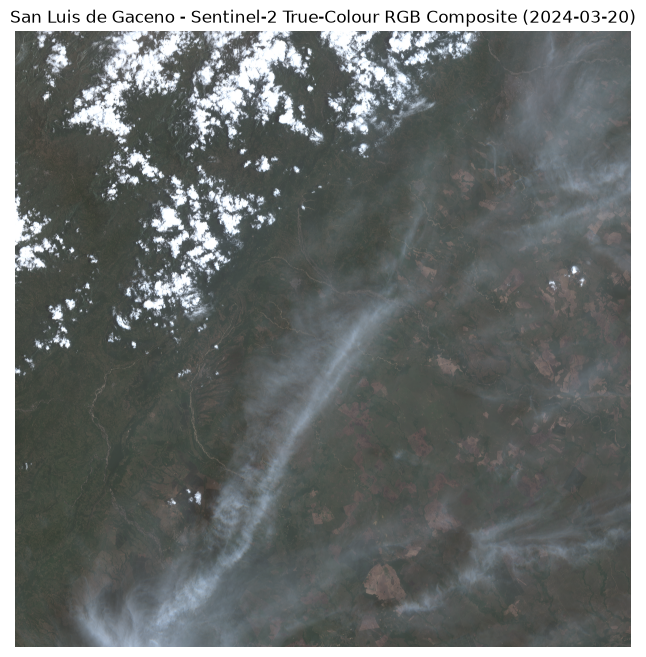

In [55]:
plt.figure(figsize=(10, 8))

# Apply a non-linear gamma correction (gamma = 0.75) directly within imshow to selectively brighten mid-tones
# (e.g. dense canopy cover) while clamping pixel values to [0.0, 1.0] for optimal, non-destructive visual rendering
plt.imshow(np.clip(np.power(rgb_normalised, 0.75), 0, 1))
plt.title("San Luis de Gaceno - Sentinel-2 True-Colour RGB Composite (2024-03-20)")
plt.axis("off")
plt.show()

##  6. Zero-Disk In-Memory Web GIS Visualisation via Rioxarray, Leaflet, and MapLibre GL

While static image previews generated via Matplotlib provide a rapid mechanism for inspecting raster output, interactive Web GIS platforms require full cartographic context and dynamic tile-streaming capability. Up to this point, the spectral bands have been processed in memory as unreferenced numerical NumPy arrays, temporarily detached from real-world coordinates.

To overlay our enhanced True-Colour composite onto interactive web maps without exporting intermediate GeoTIFF files to disk, this section establishes a zero-disk spatial binding pipeline:

1. **Geospatial Header Extraction:** Retrieve the native Coordinate Reference System and 6-parameter Affine Transformation Matrix (`transform`) from the source dataset headers using `rasterio`.
2. **8-Bit Quantisation & Visual Parity:** Rescale the gamma-corrected floating-point reflectance values ($[0.0, 1.0]$) to an 8-bit unsigned integer byte range ($[0, 255]$, `np.uint8`), ensuring exact colour luminance parity between Matplotlib (`imshow`) and web tile rendering engines.
3. **In-Memory Metadata Binding (`rioxarray`):** Reorder array axes to geospatial layout $(\text{Bands}, Y, X)$ and bind the spatial reference parameters directly into an `xarray.DataArray` structure in RAM.
4. Stream the georeferenced array directly to interactive client canvases, evaluating two distinct architectural paradigms:
   * **Option A — Standard Leaflet (`ipyleaflet`):** CPU-bound 2D raster overlay with native Google Maps satellite integration.
   * **Option B — WebGL MapLibre (`maplibregl`):** GPU-accelerated 3D vector styling with dynamic camera controls and high-frame-rate pan/zoom performance.

### 6.1. Extracting Geospatial Metadata (CRS & Affine Transform)

Although the spectral pixel values are already loaded in memory as NumPy arrays, they currently lack spatial reference parameters. To properly position and render this imagery on an interactive GIS canvas, we need to extract the original spatial header metadata from the remote dataset.

We open a temporary dataset handle on **Band 4** via `rasterio` to retrieve three fundamental spatial properties:

* **Affine Transformation Matrix (`src.transform`):** Defines the six-parameter mathematical relationship mapping array matrix indexes `(row, column)` to real-world ground coordinates `(X, Y)`. It includes the pixel pixel resolution ($10\text{ m} \times -10\text{ m}$) and the top-left spatial origin coordinates.
* **Coordinate Reference System (`src.crs`):** Specifies the projected coordinate system used by the scene (e.g. WGS 84 / UTM Zone 18N, EPSG:32618).
* **Bounding Extent (`src.bounds`):** Defines the spatial bounding envelope ($x_{\min}, y_{\min}, x_{\max}, y_{\max}$) covering the geographical coverage area of the scene.



In [56]:
# Extract the affine transformation matrix and Coordinate Reference System (CRS)
with rasterio.Env(session=rio_session, AWS_VIRTUAL_HOSTING="FALSE"):
    with rasterio.open(url_b04) as src:
        affine_transform = src.transform  # Affine transformation matrix
        crs = src.crs  # Coordinate Reference System (e.g. EPSG:32618)
        bounds = src.bounds  # Spatial bounding box (xmin, ymin, xmax, ymax)

print("Affine Transform:", affine_transform)
# Typical output: Affine(10.0, 0.0, 600000.0, 0.0, -10.0, 5000000.0)

Affine Transform: | 10.00, 0.00, 699960.00|
| 0.00,-10.00, 600000.00|
| 0.00, 0.00, 1.00|


#### Understanding the Affine Transformation Matrix in Georeferenced Rasters

In spatial data processing, a raw NumPy array is merely a two- or three-dimensional grid of numerical values without any geographic context. The **Affine Transformation Matrix** provides the mathematical mapping that links matrix pixel coordinates (row, column indices) to real-world spatial coordinates (e.g. UTM Eastings and Northings in metres, or WGS84 Geographic Longitude and Latitude).

For any pixel located at column index $\text{col}$ and row index $\text{row}$, the corresponding geographic coordinate $(X, Y)$ is computed using the $3 \times 3$ affine transformation matrix:

$$\begin{bmatrix} X \\ Y \\ 1 \end{bmatrix} =  \begin{bmatrix}  a & b & c \\  d & e & f \\  0 & 0 & 1  \end{bmatrix}  \begin{bmatrix} \text{col} \\ \text{row} \\ 1 \end{bmatrix}$$

In Python libraries such as `rasterio` and GDAL, this matrix is represented as `Affine(a, b, c, d, e, f)`.

---

#### Matrix Elements and Spatial Representation

| Parameter | Coefficient Name | Primary Geographic Function | Sentinel-2 Example (10m) |
| :--- | :--- | :--- | :--- |
| **`a`** | $x$-scale / Pixel Width | Horizontal resolution (spatial width of a pixel along the $X$-axis). | $+10.0\text{ m}$ |
| **`b`** | $x$-shear / Row Rotation | Rotation factor along rows (usually $0.0$ for standard north-up rasters). | $0.0$ |
| **`c`** | $x$-origin / Easting ($X_0$) | The absolute $X$-coordinate of the top-left corner of the top-left pixel. | $600000.0\text{ m}$ |
| **`d`** | $y$-shear / Column Rotation | Rotation factor along columns (usually $0.0$ for standard north-up rasters). | $0.0$ |
| **`e`** | $y$-scale / Pixel Height | Vertical resolution along the $Y$-axis. **Always negative** for north-up rasters. | $-10.0\text{ m}$ |
| **`f`** | $y$-origin / Northing ($Y_0$) | The absolute $Y$-coordinate of the top-left corner of the top-left pixel. | $5000000.0\text{ m}$ |

---

Extracting `src.transform` directly from the remote S3 header captures parameters $a$ through $f$. Combining this matrix with the Coordinate Reference System (CRS) allows interactive viewers like `leafmap` to place raw arrays accurately onto interactive map canvases without altering pixel values.

Let´s see what the rgb_normalised looks like

In [57]:
rgb_normalised

array([[[0.1934, 0.2102, 0.1888],
        [0.1926, 0.2092, 0.1882],
        [0.1929, 0.207 , 0.1852],
        ...,
        [0.2588, 0.2556, 0.2548],
        [0.2632, 0.2578, 0.2538],
        [0.2636, 0.2572, 0.2592]],

       [[0.1964, 0.2136, 0.1896],
        [0.1954, 0.2116, 0.1896],
        [0.1934, 0.2092, 0.1882],
        ...,
        [0.26  , 0.2544, 0.258 ],
        [0.2622, 0.257 , 0.256 ],
        [0.2588, 0.257 , 0.2544]],

       [[0.1976, 0.2172, 0.1916],
        [0.195 , 0.2132, 0.1926],
        [0.1934, 0.2078, 0.1896],
        ...,
        [0.2622, 0.2576, 0.2566],
        [0.2594, 0.2584, 0.2582],
        [0.2558, 0.2538, 0.2542]],

       ...,

       [[0.2028, 0.202 , 0.1702],
        [0.2166, 0.2136, 0.1807],
        [0.2122, 0.2082, 0.1811],
        ...,
        [0.2248, 0.217 , 0.2082],
        [0.223 , 0.219 , 0.2116],
        [0.2252, 0.2204, 0.2074]],

       [[0.1816, 0.1888, 0.162 ],
        [0.2046, 0.1984, 0.1708],
        [0.2072, 0.2006, 0.1696],
        .

### 6.2. In-Memory Processing and Spatial Metadata Binding

To ensure optimal visual brightness and performance, the processing workflow performs three in-memory transformations before passing the array to any Web GIS backend:

1. **Non-Linear Gamma Correction ($\gamma = 0.75$):** Lifts mid-tone reflectance across canopy cover.
2. **8-Bit Dynamic Range Casting:** Scales floating-point values ($0.0\text{--}1.0$) to an 8-bit unsigned integer range ($0\text{--}255$, `np.uint8`). This delivers exact colour and brightness parity between Matplotlib (`imshow`) and Web GIS tile servers.
3. **Spatial Metadata Binding:** Reorders array axes from visual $(Y, X, \text{Band})$ to geospatial $(\text{Band}, Y, X)$ and attaches the CRS and 6-parameter affine transformation matrix using `rioxarray`.

In [58]:
import numpy as np
import rioxarray
import xarray as xr

# 1. Apply non-linear gamma correction (gamma = 0.75) to lift mid-tone reflectance across canopy cover
rgb_enhanced = np.clip(np.power(rgb_normalised, 0.75), 0, 1)

# 2. Scale float array [0.0, 1.0] to 8-bit integer range [0, 255] and cast to uint8
# This ensures exact colour luminance parity between Matplotlib imshow() and Leafmap web tile engines
rgb_uint8 = (rgb_enhanced * 255).astype(np.uint8)

# 3. Transpose array from visual (Y, X, Band) to geospatial (Band, Y, X) ordering
# and construct an xarray.DataArray with explicit dimension labels required by rioxarray
da = xr.DataArray(
    rgb_uint8.transpose(2, 0, 1),
    dims=["band", "y", "x"],
)

# 4. Attach spatial reference metadata (CRS and Affine transformation matrix) to the DataArray
da = da.rio.write_crs(crs)
da = da.rio.write_transform(affine_transform)

#### Option A: 2D Visualisation via Standard Leaflet (`ipyleaflet`)

This approach uses the standard Leaflet 2D rendering engine. It is ideal when native Google Maps tile integration (`google_map="HYBRID"`) is required or when working in environments without GPU acceleration.

* **Coordinate Syntax:** Uses standard geographical ordering **`[Latitude, Longitude]`** (`[4.82, -73.17]`).
* **Basemap Engine:** Loads raster basemaps directly via tile providers.

In [59]:
import leafmap

# Render georeferenced 8-bit array directly on the interactive Leaflet map canvas
m_leaflet = leafmap.Map(center=[4.82, -73.17], zoom=11, google_map="HYBRID")
m_leaflet.add_raster(
    da, bands=[1, 2, 3], layer_name="Sentinel-2 True-Colour (Leaflet 2D)"
)
m_leaflet

Map(center=[4.9275805, -72.70144250000001], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

#### Option B: WebGL-Accelerated Visualisation via MapLibre GL (`maplibregl`)

This approach utilizes the MapLibre GL WebGL engine, enabling GPU-accelerated rendering, smooth zoom transitions, vector basemaps, and dynamic 3D terrain rotation.

* **Coordinate Syntax:** Strictly requires cartographic ordering **`[Longitude, Latitude]`** (`[-73.17, 4.82]`).
* **Basemap Engine:** Replaces static tile providers with vector style specifiers such as `style="3d-hybrid"`.

In [60]:
import leafmap.maplibregl as leafmap

# Renderizar usando el estilo libre 'liberty' (sin necesidad de API Key)
m_maplibre = leafmap.Map(center=[-73.17, 4.82], zoom=11, style="liberty")
m_maplibre.add_raster(
    da, bands=[1, 2, 3], layer_name="Sentinel-2 True-Colour (MapLibre WebGL)"
)
m_maplibre

Html(children=[<leafmap.maplibregl.Map object at 0x0000019F3A4AD950>, Card(children=[Btn(children=[Icon(childr…

### 🧠 Student Reflection Leaflet vs MapLibre GL

Before moving on to the next section of the notebook, take a moment to reflect on the two Web GIS visualisations. Consider the following key questions and experiment with your code to test your understanding:

---
* **Question:** Why did Leaflet accept `center=[4.82, -73.17]` while MapLibre required `center=[-73.17, 4.82]`?
* **To Investigate:** What happens if you intentionally swap the coordinates in MapLibre? Where on the globe does your map center end up, and why is this one of the most common bugs in automated GIS pipelines?

* **Question:** When panning and zooming across the Sentinel-2 image, did you notice any difference in smoothness or rendering speed between the two maps?
* **To Investigate:** Open your browser's Developer Tools (F12) and inspect the rendering performance. Which engine relies on standard CPU/DOM tiles, and which leverages your GPU via WebGL shaders?

* **Question:** How does a flat, top-down 2D view compare to an angled 3D view when analysing high-relief topography like the Andes surrounding San Luis de Gaceno?
* **To Investigate:** In your MapLibre code cell, add `pitch=45` and `bearing=30` to `leafmap.Map()`. How does tilting the camera change your spatial interpretation of the canopy and valleys?

* **Question:** Why was `google_map="HYBRID"` available out of the box in Leaflet, but raised a `ValidationError` in MapLibre?
* **To Investigate:** What are the advantages and disadvantages of relying on proprietary commercial basemaps (like Google Maps) versus open vector tile specifications (like MapLibre/MapTiler or Esri)?

---

> **Key Takeaway to Remember:** There is no single "best" mapping library. Standard Leaflet is ideal for quick 2D overlays and familiar basemaps, whereas MapLibre GL shines when you need high-performance GPU rendering, 3D camera controls, and interactive vector styles.

## 7. Cloud-Native Spatial Subsetting, Local GeoTIFF Export, and Verification

This section details the end-to-end workflow for extracting a targeted spatial subset directly from Sentinel-2 L2A granules hosted on Copernicus AWS S3 storage, assembling a multi-band True-Colour composite, and exporting a fully georeferenced local GeoTIFF.

By executing server-side cropping on remote JP2 assets via GDAL's virtual file system (`/vsis3/`), this pipeline bypasses the need to download gigabyte-scale full scenes, drastically reducing memory overhead and network latency.

### 7.1. Cloud-Native Spatial Subsetting and Multi-Band Array Assembly

This step performs server-side spatial subsetting directly against remote Copernicus S3 assets without downloading full-scene granules. By leveraging GDAL's virtual file system (`/vsis3/`) alongside `rasterio.mask`, pixel data within a target Area of Interest (AOI) bounding box are selectively streamed over the network.


1. Configures an authenticated `AWSSession` via `boto3` to connect to the Copernicus Data Space Ecosystem S3 endpoint.
2. Constructs a geographic bounding box in WGS 84 coordinates (`EPSG:4326`) around San Luis de Gaceno using `shapely` and `geopandas`.
3. Reprojects the vector geometry to match the scene's native UTM projection (`EPSG:32618`) and clips each spectral band on the fly inside an isolated `rasterio.Env` context manager.
4. Combines individual clipped 2D spectral arrays (Red, Green, Blue) into a unified 3D array $(\text{Bands}, Y, X)$.
5. Updates the geospatial metadata profile (`GTiff` driver, clipped dimensions, affine transform, CRS, and `nodata` mask) in preparation for raster writing.

In [61]:
import rasterio
from rasterio.mask import mask
from rasterio.session import AWSSession
import geopandas as gpd
from shapely.geometry import box


# 1. Define S3 paths for Bands 4 (Red), 3 (Green), and 2 (Blue)
url_b04 = "/vsis3/eodata/Sentinel-2/MSI/L2A/2024/03/20/S2B_MSIL2A_20240320T151719_N0510_R125_T18NYL_20240320T205658.SAFE/GRANULE/L2A_T18NYL_A036759_20240320T151846/IMG_DATA/R10m/T18NYL_20240320T151719_B04_10m.jp2"
url_b03 = url_b04.replace("B04_10m.jp2", "B03_10m.jp2")  # Band 3 (Green)
url_b02 = url_b04.replace("B04_10m.jp2", "B02_10m.jp2")  # Band 2 (Blue)

# 2. Initialise the boto3 session and AWSSession for S3 authentication
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

endpoint = os.environ.get("AWS_S3_ENDPOINT", "eodata.dataspace.copernicus.eu")
if not endpoint.startswith("http"):
    endpoint = f"https://{endpoint}"

rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

# 3. Create a sample Area of Interest (AOI) GeoDataFrame near San Luis de Gaceno (EPSG:4326)
min_lon, min_lat = -73.20, 4.80
max_lon, max_lat = -73.14, 4.85
aoi_polygon = box(min_lon, min_lat, max_lon, max_lat)
gdf_aoi = gpd.GeoDataFrame({"geometry": [aoi_polygon]}, crs="EPSG:4326")

# Helper function to safely open, clip, and return array data within an isolated GDAL session
def clip_s3_band(url, session, gdf_aoi):
    """Safely opens an S3 raster dataset, reprojects AOI geometry, clips the raster, and closes handles."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            # Reproject AOI geometry to match the dataset's native CRS (UTM Zone 18N)
            gdf_utm = gdf_aoi.to_crs(src.crs)
            shapes = [geom for geom in gdf_utm.geometry]
            
            # Clip raster using spatial mask
            clipped_data, transform = mask(src, shapes, crop=True)
            meta = src.meta.copy()
            
            return clipped_data, transform, meta

# 4. Read and clip each spectral band safely using isolated GDAL environments
print("Clipping Band 4 (Red)...")
clipped_r, out_transform, out_meta = clip_s3_band(url_b04, rio_session, gdf_aoi)

print("Clipping Band 3 (Green)...")
clipped_g, _, _ = clip_s3_band(url_b03, rio_session, gdf_aoi)

print("Clipping Band 2 (Blue)...")
clipped_b, _, _ = clip_s3_band(url_b02, rio_session, gdf_aoi)

# 5. Stack clipped 2D arrays into a 3D multi-band array (Bands, Height, Width)
clipped_rgb = np.vstack([clipped_r, clipped_g, clipped_b])

# 6. Update metadata profile for multi-band GeoTIFF output
out_meta.update({
    "driver": "GTiff",
    "height": clipped_rgb.shape[1],
    "width": clipped_rgb.shape[2],
    "transform": out_transform,
    "count": 3,
    "nodata": 0
})



Clipping Band 4 (Red)...
Clipping Band 3 (Green)...
Clipping Band 2 (Blue)...


### 7.2. Multi-Band GeoTIFF Export, Metadata Tagging, and Visual Verification

Complete the cloud-native spatial subsetting workflow by exporting the clipped 3D spectral array to a local multi-band GeoTIFF file, embedding custom metadata tags, and validating the exported file structure.

1.  Exports the stacked array (`clipped_rgb`) to disk using the updated spatial metadata profile (`out_meta`), preserving spatial extent and CRS alignment.
2.  Injects explicit band labels (`B04 - Red`, `B03 - Green`, `B02 - Blue`) into the GeoTIFF header using `set_band_description()` to ensure dataset provenance and GIS interoperability.
3.  Reopens the generated file to verify dataset integrity, confirming total band count and custom channel descriptions.
4.  Reads the exported raster, transposes array axes from $(\text{Channels}, Y, X)$ to visual $(Y, X, \text{Channels})$ ordering using `np.moveaxis()`, and rescales surface reflectance for Matplotlib rendering.

In [62]:
#  Write multi-band GeoTIFF and assign custom band descriptions
output_geotiff = "san_luis_de_gaceno_rgb_clipped.tif"

with rasterio.open(output_geotiff, "w", **out_meta) as dst:
    dst.write(clipped_rgb)
    
    # Assign specific spectral band names to dataset metadata
    dst.set_band_description(1, "B04 - Red (10m)")
    dst.set_band_description(2, "B03 - Green (10m)")
    dst.set_band_description(3, "B02 - Blue (10m)")

print(f"✅ Clipped GeoTIFF successfully exported to: {output_geotiff}")

# 8. Verify saved file metadata and display the clipped True-Colour composite
with rasterio.open(output_geotiff) as verification_src:
    print("\n--- Exported GeoTIFF Metadata Verification ---")
    print("Band count:", verification_src.count)
    print("Custom band names:", verification_src.descriptions)
    
    # Read stacked bands for visualisation
    rgb_data = verification_src.read()
    
    # Rearrange array shape from (Channels, Height, Width) to (Height, Width, Channels) for Matplotlib
    rgb_display = np.moveaxis(rgb_data, 0, -1)
    rgb_normalised = np.clip(rgb_display / 3000.0, 0, 1)


✅ Clipped GeoTIFF successfully exported to: san_luis_de_gaceno_rgb_clipped.tif

--- Exported GeoTIFF Metadata Verification ---
Band count: 3
Custom band names: ('B04 - Red (10m)', 'B03 - Green (10m)', 'B02 - Blue (10m)')


### 7.3. True-Colour Visualisation of the Clipped Raster

This final step displays the cropped multi-band raster composite to confirm spatial extent accuracy and visual quality before proceeding to interactive GIS rendering.

* **Canvas Setup:** Configures a square $8 \times 8$ inch figure canvas for optimal display resolution.
* **Array Rendering:** Uses `plt.imshow()` to render the normalised RGB reflectance array ($[0.0, 1.0]$ floating-point range).
* **Cartographic Formatting:** Suppresses tick marks and axis borders (`plt.axis("off")`) to produce a clean map preview of the San Luis de Gaceno region.

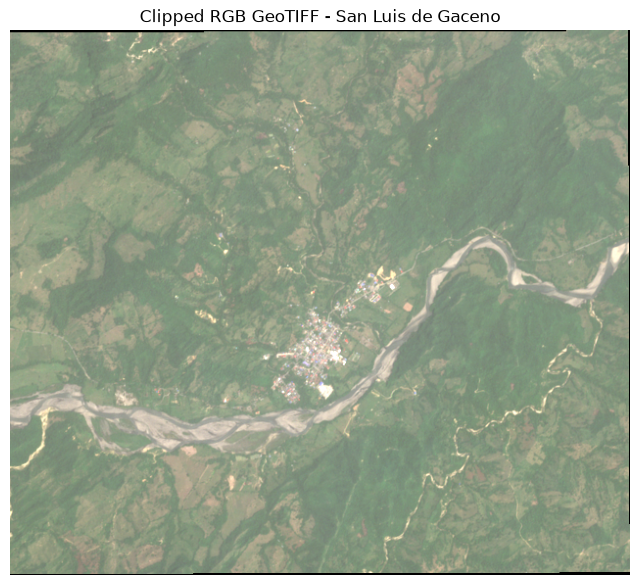

In [63]:
# Render the clipped RGB image
plt.figure(figsize=(8, 8))
plt.imshow(rgb_normalised)
plt.title("Clipped RGB GeoTIFF - San Luis de Gaceno")
plt.axis("off")
plt.show()

## 6. Hands-On Project

### Objective
Apply the cloud geospatial data workflow (CDSE, `leafmap`, `rasterio`, and `xarray`) to perform a multi-temporal change detection analysis on a study area of your choice.

---

### Project Guidelines

1. Select a study area relevant to your research project. Load a vector file (`.geojson`, `.gpkg`, or `.shp`) defining your AOI and extract its geometry.

2. Query the CDSE OData API for a specific product of your choice. Select **two distinct acquisition dates** (e.g., dry vs. rainy season, pre- vs. post-extreme event, or interannual comparison).

3. Access the relevant spectral bands directly via S3 using the `/vsis3/` virtual file system without downloading the entire product locally, and mask or clip the datasets to your AOI.
   * Calculate a **difference or change image**  to quantify spatial changes across time.
   * Export the generated difference raster locally as a GeoTIFF file (`.tif` or `.tiff`) using `rasterio` or `rioxarray`, ensuring proper georeferencing and spatial reference system (CRS) preservation.

4. Render the State 1 image, State 2 image, and Difference image on an interactive map using `leafmap` with an appropriate divergent colour palette (e.g., `RdYlGn` or `coolwarm`). Incorporate additional map controls into your `leafmap` interface to enhance usability (e.g., `split_map` / swipe control, layer control, scale bar, minimap, draw control, or full-screen mode).
   * Include a histogram and basic descriptive statistics (mean, min, max, standard deviation) for the pixel difference distribution.

5. Prepare a **5-minute live demonstration** of your findings to present directly to the class. No slide deck is required: you will present your workflow, interactive maps, and spatial insights directly by walking through your executed Jupyter Notebook.



## 7. Assessment Rubric


| Criterion & Weighting | Insufficient (1) | Satisfactory / Basic (2) | Good / Proficient (3) | Excellent  (4) |
| :--- | :--- | :--- | :--- | :--- |
| **1. Visualisation & Map Controls (25%)** | Map is static or lacks divergent palettes. No additional interactive map controls or summary statistics provided. | Renders interactive maps in `leafmap` but lacks divergent palettes or includes only 1 basic map control. Histogram is unclear or missing. | Well-symbolised interactive maps (e.g., `coolwarm`/`RdYlGn`), includes at least 2 additional controls (e.g., *split map*, *scalebar*), and clear histogram. | Advanced interactive setup: integrates multiple controls (e.g., *swipe control*, *minimap*, *draw tool*), polished styling, and full descriptive statistics. |
| **2. Code Mastery & Technical Explanation (25%)** | Reads code line-by-line without understanding underlying geospatial/S3 logic; struggles to explain own syntax. | Explains code functionality at a surface level; hesitant when explaining spatial operations or S3 array manipulation. | Explains code logic, S3 data streaming, and index syntax fluently without reading raw lines. | Demonstrates complete command of code architecture; articulates spatial operations, raster logic, and functions with expert clarity. |
| **3. Time Management (25%)** | Significantly fails time limit (<3 mins or >7 mins); cut short before presenting key maps or results. | Over or under time significantly (3–4 mins or 6–7 mins); uneven pacing across notebook sections. | Well-paced and close to the target (4.5–5.5 mins); covers workflow, maps, and conclusions smoothly. | Precise 5-minute delivery; impeccably structured walkthrough of notebook, maps, and findings without rushing. |
| **4. Response to Q&A (25%)** | Unable to answer basic questions regarding workflow, parameter choices, or spatial findings. | Answers questions partially or hesitatingly; requires promptings or hints to clarify analytical choices. | Answers technical questions accurately and confidently regarding methodology and parameter selection. | Responds with technical depth, precision, and authority; defends analytical choices and spatial insights effortlessly. |